<a href="https://colab.research.google.com/github/AvCodeLyn/USA_WENEZUELA_1.09.2025-10.01.2026/blob/main/Analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza relacji USA–Wenezuela na podstawie GDELT 2.1 (01.09.2025–10.01.2026)
**Autorzy:** Maciej Król, Wiktoria Bielec, Konrad Lubaski


<a href="https://colab.research.google.com/github/AvCodeLyn/USA_WENEZUELA_1.09.2025-10.01.2026/blob/main/Analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza dynamiki zdarzeń medialnych związanych z konfliktem USA–Wenezuela na podstawie danych GDELT 2.1 – Events.

## Kontekst i cel analizy
Analiza dotyczy relacji USA–Wenezuela w okresie **01.09.2025–10.01.2026** na podstawie zbioru **GDELT 2.1 – Events**.
Skupiamy się na zdarzeniach, w których **USA i Wenezuela występują jako aktorzy** (Actor1/Actor2).


## Pytania badawcze i hipotezy
**P1.** Czy w oknie 03–09.01.2026 wystąpił skokowy wzrost wolumenu zdarzeń i artykułów?
**H1.** W oknie 03–09.01.2026 obserwujemy istotny pik wolumenu.

**P2.** Czy struktura zdarzeń w piku różni się od okresu bazowego?
**H2.** W piku rośnie udział zdarzeń siłowych (m.in. 17x/18x/19x) oraz 173 (areszt).

**P3.** Czy narracja przesuwa się w stronę konfliktu materialnego?
**H3.** W piku wzrasta udział **Material Conflict (QuadClass=4)** względem **Verbal Conflict (QuadClass=3)**.

**P4.** Czy ton narracji i GoldsteinScale ulegają pogorszeniu w piku?
**H4.** AvgTone i GoldsteinScale są istotnie bardziej ujemne w oknie piku niż w baseline.

**P5.** Czy w piku rośnie koncentracja aktorów i źródeł?
**H5.** W piku dominują wybrane źródła oraz wąski zestaw aktorów.


## Wymagania przedmiotowe – mapowanie do tego projektu
Poniżej wskazujemy, gdzie w notebooku realizowane są elementy wymagane na przedmiot:
- **Załadowanie danych do DataFrame** – wczytanie danych GDELT do Spark i konwersje do Pandas.
- **Pre-processing** – filtrowanie USA–Wenezuela, konwersja dat, agregacje dzienne i tygodniowe.
- **Analiza wizualna** – wykresy wolumenu, CAMEO, QuadClass, AvgTone, GoldsteinScale.
- **Analiza statystyczna** – statystyki opisowe, rozkłady, testy statystyczne.
- **Zaawansowana analiza** – szeregi czasowe, trend/rolling, komponenty sezonowe, prosta predykcja.
- **Podsumowanie i wnioski** – sekcja końcowa.
- **Dokumentacja** – sekcje końcowe zawierają wskazówki do raportu i prezentacji.


### Pobranie danych

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT_NAME = "gdelt_trump_venezuela"
BASE_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME

DIRS = {
    "config": BASE_DIR / "00_config",
    "raw_zips": BASE_DIR / "01_raw" / "zips",
    "raw_csv": BASE_DIR / "01_raw" / "csv",
    "curated": BASE_DIR / "02_curated",
    "outputs_figures": BASE_DIR / "03_outputs" / "figures",
    "outputs_tables": BASE_DIR / "03_outputs" / "tables",
    "outputs_reports": BASE_DIR / "03_outputs" / "reports",
    "logs": BASE_DIR / "04_logs",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

print("Project base:", BASE_DIR)
for k, v in DIRS.items():
    print(f"{k:>15}: {v}")





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project base: /content/drive/MyDrive/gdelt_trump_venezuela
         config: /content/drive/MyDrive/gdelt_trump_venezuela/00_config
       raw_zips: /content/drive/MyDrive/gdelt_trump_venezuela/01_raw/zips
        raw_csv: /content/drive/MyDrive/gdelt_trump_venezuela/01_raw/csv
        curated: /content/drive/MyDrive/gdelt_trump_venezuela/02_curated
outputs_figures: /content/drive/MyDrive/gdelt_trump_venezuela/03_outputs/figures
 outputs_tables: /content/drive/MyDrive/gdelt_trump_venezuela/03_outputs/tables
outputs_reports: /content/drive/MyDrive/gdelt_trump_venezuela/03_outputs/reports
           logs: /content/drive/MyDrive/gdelt_trump_venezuela/04_logs


In [2]:
from datetime import datetime, timezone
import json
import platform
import sys

START_DATE = "2025-09-01"
END_DATE   = "2026-01-10"

# Cache / odtwarzalność
REBUILD_RAW = False        # True = pobierz i rozpakuj wszystko od nowa
REBUILD_CURATED = False    # True = przebuduj curated (np. Parquet) od nowa
REBUILD_OUTPUTS = True     # zwykle OK regenerować wykresy/tabele

CONFIG_PATH = DIRS["config"] / "config.json"
RUN_METADATA_PATH = DIRS["logs"] / "run_metadata.json"

config = {
    "PROJECT_NAME": PROJECT_NAME,
    "START_DATE": START_DATE,
    "END_DATE": END_DATE,
    "REBUILD_RAW": REBUILD_RAW,
    "REBUILD_CURATED": REBUILD_CURATED,
    "REBUILD_OUTPUTS": REBUILD_OUTPUTS,
}

run_metadata = {
    "run_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "config": config,
    "env": {
        "python": sys.version,
        "platform": platform.platform(),
    },
    "dirs": {k: str(v) for k, v in DIRS.items()},
}

CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
RUN_METADATA_PATH.write_text(json.dumps(run_metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved:", CONFIG_PATH)
print("Saved:", RUN_METADATA_PATH)
print("Config:", config)





Saved: /content/drive/MyDrive/gdelt_trump_venezuela/00_config/config.json
Saved: /content/drive/MyDrive/gdelt_trump_venezuela/04_logs/run_metadata.json
Config: {'PROJECT_NAME': 'gdelt_trump_venezuela', 'START_DATE': '2025-09-01', 'END_DATE': '2026-01-10', 'REBUILD_RAW': False, 'REBUILD_CURATED': False, 'REBUILD_OUTPUTS': True}


In [3]:
# Ustawienia stylu wykresów (Poppins + spójny wygląd)
import os
import urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns

def ensure_poppins():
    font_name = 'Poppins'
    if any(font_name in f.name for f in font_manager.fontManager.ttflist):
        return
    url = 'https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf'
    font_dir = os.path.join(os.getcwd(), 'fonts')
    os.makedirs(font_dir, exist_ok=True)
    font_path = os.path.join(font_dir, 'Poppins-Regular.ttf')
    if not os.path.exists(font_path):
        urllib.request.urlretrieve(url, font_path)
    font_manager.fontManager.addfont(font_path)

ensure_poppins()
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.family': 'Poppins',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'regular',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})





In [4]:
!pip -q install pyspark==3.5.1

import os
import zipfile
import requests
from pathlib import Path
from datetime import datetime, timedelta

from pyspark.sql import SparkSession, functions as F, types as T

spark = (SparkSession.builder
         .appName("gdelt_trump_venezuela")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())

print("Spark:", spark.version)





Spark: 3.5.1


In [5]:
GDELT_EVENTS_BASE = "http://data.gdeltproject.org/events"


DATE_FMT = "%Y-%m-%d"

def daterange_days(start_date: str, end_date: str):
    s = datetime.strptime(start_date, DATE_FMT).date()
    e = datetime.strptime(end_date, DATE_FMT).date()
    if e < s:
        raise ValueError("END_DATE < START_DATE")
    out = []
    cur = s
    while cur <= e:
        out.append(cur.strftime("%Y%m%d"))
        cur += timedelta(days=1)
    return out

DAYS = daterange_days(START_DATE, END_DATE)
print("Zakres dni:", len(DAYS), "dni, od", DAYS[0], "do", DAYS[-1])

def gdelt_zip_url(yyyymmdd: str) -> str:
    return f"{GDELT_EVENTS_BASE}/{yyyymmdd}.export.CSV.zip"

def local_zip_path(yyyymmdd: str) -> Path:
    return DIRS["raw_zips"] / f"{yyyymmdd}.export.CSV.zip"

def local_csv_path(yyyymmdd: str) -> Path:
    return DIRS["raw_csv"] / f"{yyyymmdd}.export.CSV"





Zakres dni: 132 dni, od 20250901 do 20260110


In [6]:
import time
from datetime import datetime, timezone
from pathlib import Path

DOWNLOAD_LOG = DIRS["logs"] / "download_log.csv"

def append_line(path: Path, line: str):
    with open(path, "a", encoding="utf-8") as f:
        f.write(line)

# nagłówek logu jeśli nie ma
if not DOWNLOAD_LOG.exists():
    DOWNLOAD_LOG.write_text("date,url,status,bytes,local_path,from_cache,ts_utc\n", encoding="utf-8")

# (opcjonalnie) usuń wcześniejsze 0B zipy i .part
for p in DIRS["raw_zips"].glob("*.zip"):
    if p.stat().st_size == 0:
        p.unlink()
for p in DIRS["raw_zips"].glob("*.part"):
    p.unlink()

downloaded = 0
skipped = 0
failed = 0

total = len(DAYS)

for i, d in enumerate(DAYS, start=1):
    url = gdelt_zip_url(d)
    zpath = local_zip_path(d)

    # cache
    if (not REBUILD_RAW) and zpath.exists() and zpath.stat().st_size > 0:
        skipped += 1
        append_line(DOWNLOAD_LOG, f"{d},{url},200,{zpath.stat().st_size},{zpath},1,{datetime.now(timezone.utc).isoformat()}\n")
        if i % 10 == 0 or i == total:
            print(f"[{i}/{total}] pobrane={downloaded}, cache={skipped}, fail={failed}")
        continue

    tmp = zpath.with_suffix(zpath.suffix + ".part")

    # wget: retries + timeout + retry na problemy sieci
    # -q: mniej spamu; status wnioskujemy z kodu wyjścia i rozmiaru
    cmd = f'wget -q --timeout=30 --tries=3 --waitretry=2 --retry-connrefused -O "{tmp}" "{url}"'
    rc = os.system(cmd)

    if rc == 0 and tmp.exists() and tmp.stat().st_size > 0:
        tmp.replace(zpath)
        downloaded += 1
        append_line(DOWNLOAD_LOG, f"{d},{url},200,{zpath.stat().st_size},{zpath},0,{datetime.now(timezone.utc).isoformat()}\n")
    else:
        failed += 1
        # sprzątanie po nieudanym pobraniu
        if tmp.exists():
            tmp.unlink()
        append_line(DOWNLOAD_LOG, f"{d},{url},{rc},0,{zpath},0,{datetime.now(timezone.utc).isoformat()}\n")

    # lekki throttling, żeby nie walić serwera
    time.sleep(0.15)

    if i % 5 == 0 or i == total:
        print(f"[{i}/{total}] pobrane={downloaded}, cache={skipped}, fail={failed}")

print("DONE | Pobrane:", downloaded, "| Pominięte(cache):", skipped, "| Niepowodzenie:", failed)
print("Log:", DOWNLOAD_LOG)





[10/132] pobrane=0, cache=10, fail=0
[20/132] pobrane=0, cache=20, fail=0
[30/132] pobrane=0, cache=30, fail=0
[40/132] pobrane=0, cache=40, fail=0
[50/132] pobrane=0, cache=50, fail=0
[60/132] pobrane=0, cache=60, fail=0
[70/132] pobrane=0, cache=70, fail=0
[80/132] pobrane=0, cache=80, fail=0
[90/132] pobrane=0, cache=90, fail=0
[100/132] pobrane=0, cache=100, fail=0
[110/132] pobrane=0, cache=110, fail=0
[120/132] pobrane=0, cache=120, fail=0
[130/132] pobrane=0, cache=130, fail=0
[132/132] pobrane=0, cache=132, fail=0
DONE | Pobrane: 0 | Pominięte(cache): 132 | Niepowodzenie: 0
Log: /content/drive/MyDrive/gdelt_trump_venezuela/04_logs/download_log.csv


In [7]:
from datetime import datetime, timezone

PROCESSED_DAYS_LOG = DIRS["logs"] / "processed_days.csv"

if not PROCESSED_DAYS_LOG.exists():
    PROCESSED_DAYS_LOG.write_text("date,zip_exists,csv_exists,csv_bytes,ts_utc\n", encoding="utf-8")

def append_line(path: Path, line: str):
    with open(path, "a", encoding="utf-8") as f:
        f.write(line)

def unzip_one(zip_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

unpacked = 0
skipped = 0
missing_zip = 0

for d in DAYS:
    zpath = local_zip_path(d)
    cpath = local_csv_path(d)

    if (not REBUILD_RAW) and cpath.exists() and cpath.stat().st_size > 0:
        skipped += 1
        append_line(PROCESSED_DAYS_LOG, f"{d},1,1,{cpath.stat().st_size},{datetime.now(timezone.utc).isoformat()}\n")
        continue

    if not zpath.exists() or zpath.stat().st_size == 0:
        missing_zip += 1
        append_line(PROCESSED_DAYS_LOG, f"{d},0,0,0,{datetime.now(timezone.utc).isoformat()}\n")
        continue

    unzip_one(zpath, DIRS["raw_csv"])
    unpacked += 1

    if cpath.exists() and cpath.stat().st_size > 0:
        append_line(PROCESSED_DAYS_LOG, f"{d},1,1,{cpath.stat().st_size},{datetime.now(timezone.utc).isoformat()}\n")
    else:
        append_line(PROCESSED_DAYS_LOG, f"{d},1,0,0,{datetime.now(timezone.utc).isoformat()}\n")

print("Unpacked:", unpacked, "| Skipped(cache):", skipped, "| Missing ZIP:", missing_zip)
print("Log:", PROCESSED_DAYS_LOG)





Unpacked: 0 | Skipped(cache): 132 | Missing ZIP: 0
Log: /content/drive/MyDrive/gdelt_trump_venezuela/04_logs/processed_days.csv


### Załadowanie wszystkich dziennych CSV do jednego DF (Spark)
### Dane ładowane w trybie TSV bez nagłówka, sprawdzamy dane, liczbę kolumn etc.

In [8]:
from pathlib import Path

csv_glob = str(Path(DIRS["raw_csv"]) / "*.export.CSV")

df_raw = (spark.read
          .option("sep", "\t") # Separatorem w plikach GDELT jest TAB, nie przecinek. Dlatego daliśmy "\t"
          .option("quote", '"')
          .option("escape", '"')
          .option("inferSchema", "false")
          .csv(csv_glob))

print("CSV glob:", csv_glob)
print("Rows (approx, exact count may take time):", df_raw.rdd.getNumPartitions(), "partitions")
print("Columns:", len(df_raw.columns))

# Test 3 przykładowych wierszy i 10 pierwszych kolumn
df_raw.select(*df_raw.columns[:10]).show(3, truncate=120)




CSV glob: /content/drive/MyDrive/gdelt_trump_venezuela/01_raw/csv/*.export.CSV
Rows (approx, exact count may take time): 55 partitions
Columns: 58
+----------+--------+------+----+---------+----+----+----+----+----+
|       _c0|     _c1|   _c2| _c3|      _c4| _c5| _c6| _c7| _c8| _c9|
+----------+--------+------+----+---------+----+----+----+----+----+
|1262227594|20240910|202409|2024|2024.6849|NULL|NULL|NULL|NULL|NULL|
|1262227595|20240910|202409|2024|2024.6849|NULL|NULL|NULL|NULL|NULL|
|1262227596|20240910|202409|2024|2024.6849|NULL|NULL|NULL|NULL|NULL|
+----------+--------+------+----+---------+----+----+----+----+----+
only showing top 3 rows



In [9]:
# ===== [8] INSPEKCJA STRUKTURY KOLUMN (ILE I JAKIE) =====

print("Liczba kolumn w df_raw:", len(df_raw.columns))

# pokaż wszystkie indeksy i nazwy techniczne
for i, c in enumerate(df_raw.columns):
    print(f"{i:>2}: {c}")

# pokaż kilka ostatnich kolumn i wartości
df_raw.select(*df_raw.columns[-10:]).show(5, truncate=120)





Liczba kolumn w df_raw: 58
 0: _c0
 1: _c1
 2: _c2
 3: _c3
 4: _c4
 5: _c5
 6: _c6
 7: _c7
 8: _c8
 9: _c9
10: _c10
11: _c11
12: _c12
13: _c13
14: _c14
15: _c15
16: _c16
17: _c17
18: _c18
19: _c19
20: _c20
21: _c21
22: _c22
23: _c23
24: _c24
25: _c25
26: _c26
27: _c27
28: _c28
29: _c29
30: _c30
31: _c31
32: _c32
33: _c33
34: _c34
35: _c35
36: _c36
37: _c37
38: _c38
39: _c39
40: _c40
41: _c41
42: _c42
43: _c43
44: _c44
45: _c45
46: _c46
47: _c47
48: _c48
49: _c49
50: _c50
51: _c51
52: _c52
53: _c53
54: _c54
55: _c55
56: _c56
57: _c57
+--------+----+-----------------------+----+----+---------+--------+--------+--------+------------------------------------------------------------------------------------------------------------------------+
|    _c48|_c49|                   _c50|_c51|_c52|     _c53|    _c54|    _c55|    _c56|                                                                                                                    _c57|
+--------+----+-----------------------+----+-

In [10]:
# ===== [9] Nadanie nazw kolumnom (GDELT 2.1 Events: 58 kolumn, GEO bez ADM2) =====
# Wariant: Core(35) + Actor1Geo(7) + Actor2Geo(7) + ActionGeo(7) + DATEADDED + SOURCEURL

gdelt_columns_58 = [
    # --- Core (35) ---
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year", "FractionData",
    "Actor1Code", "Actor1Name", "Actor1CountryCode",
    "Actor1KnownGroupCode", "Actor1EthnicCode", "Actor1Religion1Code",
    "Actor1Religion2Code", "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode",
    "Actor2KnownGroupCode", "Actor2EthnicCode", "Actor2Religion1Code",
    "Actor2Religion2Code", "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources",
    "NumArticles", "AvgTone",

    # --- Actor1Geo (7) ---
    "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_Lat", "Actor1Geo_Long", "Actor1Geo_FeatureID",

    # --- Actor2Geo (7) ---
    "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_Lat", "Actor2Geo_Long", "Actor2Geo_FeatureID",

    # --- ActionGeo (7) ---
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long", "ActionGeo_FeatureID",

    # --- Tail (2) ---
    "DATEADDED", "SOURCEURL"
]

print("df_raw columns:", len(df_raw.columns))
print("schema columns :", len(gdelt_columns_58))

assert len(gdelt_columns_58) == len(df_raw.columns), "Still mismatched: schema != data"

df_events = df_raw.toDF(*gdelt_columns_58)

# szybki sanity check: czy ogon danych jest poprawnie zmapowany
df_events.select(
    "GLOBALEVENTID", "SQLDATE", "AvgTone",
    "Actor1Name", "Actor1CountryCode",
    "Actor2Name", "Actor2CountryCode",
    "EventCode", "NumArticles", "NumSources",
    "DATEADDED", "SOURCEURL"
).show(5, truncate=140)





df_raw columns: 58
schema columns : 58
+-------------+--------+-----------------+----------+-----------------+----------+-----------------+---------+-----------+----------+---------+--------------------------------------------------------------------------------------------------------------------------------------------+
|GLOBALEVENTID| SQLDATE|          AvgTone|Actor1Name|Actor1CountryCode|Actor2Name|Actor2CountryCode|EventCode|NumArticles|NumSources|DATEADDED|                                                                                                                                   SOURCEURL|
+-------------+--------+-----------------+----------+-----------------+----------+-----------------+---------+-----------+----------+---------+--------------------------------------------------------------------------------------------------------------------------------------------+
|   1262227594|20240910| -2.7027027027027|      NULL|             NULL|   ALBERTA|              CAN|      

## Selekcja relacji USA–Wenezuela
Tworzymy zbiór zdarzeń, w których **USA i Wenezuela występują jako aktorzy** (Actor1/Actor2).
To podstawowy filtr definiujący badaną relację w całej analizie.


In [11]:
from pyspark.sql import functions as F

# warunek: USA jako jeden z aktorów
cond_usa = (
    (F.col("Actor1CountryCode") == "USA") |
    (F.col("Actor2CountryCode") == "USA")
)

# warunek: Wenezuela jako jeden z aktorów
cond_ven = (
    (F.col("Actor1CountryCode") == "VEN") |
    (F.col("Actor2CountryCode") == "VEN")
)

# zbiór konfliktu USA–Wenezuela
df_us_ven = df_events.filter(cond_usa & cond_ven)

print("Liczba zdarzeń USA–Wenezuela:", df_us_ven.count())

# sanity check: kilka przykładowych rekordów
df_us_ven.select(
    "SQLDATE",
    "Actor1Name", "Actor1CountryCode",
    "Actor2Name", "Actor2CountryCode",
    "EventCode",
    "NumArticles", "NumSources",
    "SOURCEURL"
).show(10, truncate=140)




Liczba zdarzeń USA–Wenezuela: 38561
+--------+---------------+-----------------+---------------+-----------------+---------+-----------+----------+---------------------------------------------------------------------------------------------------------------------------------+
| SQLDATE|     Actor1Name|Actor1CountryCode|     Actor2Name|Actor2CountryCode|EventCode|NumArticles|NumSources|                                                                                                                        SOURCEURL|
+--------+---------------+-----------------+---------------+-----------------+---------+-----------+----------+---------------------------------------------------------------------------------------------------------------------------------+
|20250910|       AMERICAN|              USA|     VENEZUELAN|              VEN|      050|          6|         1|                               https://www.yahoo.com/news/articles/gabbard-retracted-intelligence-report-venezuela-201622584.ht

In [12]:
output_path = DIRS["curated"] / "events_usa_venezuela.parquet"

df_us_ven.write.mode("overwrite").parquet(str(output_path))

print("Zapisano curated dataset do:", output_path)
print("Liczba rekordów:", df_us_ven.count())




Zapisano curated dataset do: /content/drive/MyDrive/gdelt_trump_venezuela/02_curated/events_usa_venezuela.parquet
Liczba rekordów: 38561


## Dynamika wolumenu (zdarzenia i artykuły)
Analizujemy dzienną i tygodniową liczbę zdarzeń oraz artykułów, aby zidentyfikować
okresy wzmożonego zainteresowania (piki) oraz porównać je z okresem bazowym.


In [13]:
from pyspark.sql import functions as F

df_daily = (
    df_us_ven
    .groupBy("DATEADDED")
    .agg(
        F.count("*").alias("num_events"),
        F.sum("NumArticles").alias("num_articles"),
        F.sum("NumSources").alias("num_sources")
    )
    .orderBy("DATEADDED")
)

print("Liczba dni w agregacji:", df_daily.count())

df_daily.show(10)




Liczba dni w agregacji: 132
+---------+----------+------------+-----------+
|DATEADDED|num_events|num_articles|num_sources|
+---------+----------+------------+-----------+
| 20250901|        81|       654.0|      181.0|
| 20250902|       201|      2193.0|      870.0|
| 20250903|       359|      4735.0|     1331.0|
| 20250904|       287|      3098.0|     1138.0|
| 20250905|       270|      5141.0|     1614.0|
| 20250906|       263|      3895.0|      818.0|
| 20250907|       126|       625.0|      177.0|
| 20250908|       146|       846.0|      270.0|
| 20250909|       188|      1311.0|      379.0|
| 20250910|        80|       406.0|      121.0|
+---------+----------+------------+-----------+
only showing top 10 rows



In [14]:
from pyspark.sql import functions as F

# konwersja DATEADDED (YYYYMMDD) -> date
df_us_ven_dated = df_us_ven.withColumn(
    "date_added",
    F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd")
)

df_daily = (
    df_us_ven_dated
    .groupBy("date_added")
    .agg(
        F.count("*").alias("num_events"),
        F.sum("NumArticles").alias("num_articles"),
        F.sum("NumSources").alias("num_sources")
    )
    .orderBy("date_added")
)

print("Zakres dat (DATEADDED):")
df_daily.agg(
    F.min("date_added").alias("min_date"),
    F.max("date_added").alias("max_date")
).show()

print("Liczba dni w agregacji:", df_daily.count())
df_daily.show(10)






Zakres dat (DATEADDED):
+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2025-09-01|2026-01-10|
+----------+----------+

Liczba dni w agregacji: 132
+----------+----------+------------+-----------+
|date_added|num_events|num_articles|num_sources|
+----------+----------+------------+-----------+
|2025-09-01|        81|       654.0|      181.0|
|2025-09-02|       201|      2193.0|      870.0|
|2025-09-03|       359|      4735.0|     1331.0|
|2025-09-04|       287|      3098.0|     1138.0|
|2025-09-05|       270|      5141.0|     1614.0|
|2025-09-06|       263|      3895.0|      818.0|
|2025-09-07|       126|       625.0|      177.0|
|2025-09-08|       146|       846.0|      270.0|
|2025-09-09|       188|      1311.0|      379.0|
|2025-09-10|        80|       406.0|      121.0|
+----------+----------+------------+-----------+
only showing top 10 rows



In [15]:
# ===== [14] Zapis agregacji dziennej (DATEADDED) do Parquet =====

out_daily = DIRS["curated"] / "daily_usa_venezuela_dateadded.parquet"

df_daily.write.mode("overwrite").parquet(str(out_daily))

print("Zapisano agregację dzienną do:", out_daily)
print("Liczba dni:", df_daily.count())




Zapisano agregację dzienną do: /content/drive/MyDrive/gdelt_trump_venezuela/02_curated/daily_usa_venezuela_dateadded.parquet
Liczba dni: 132


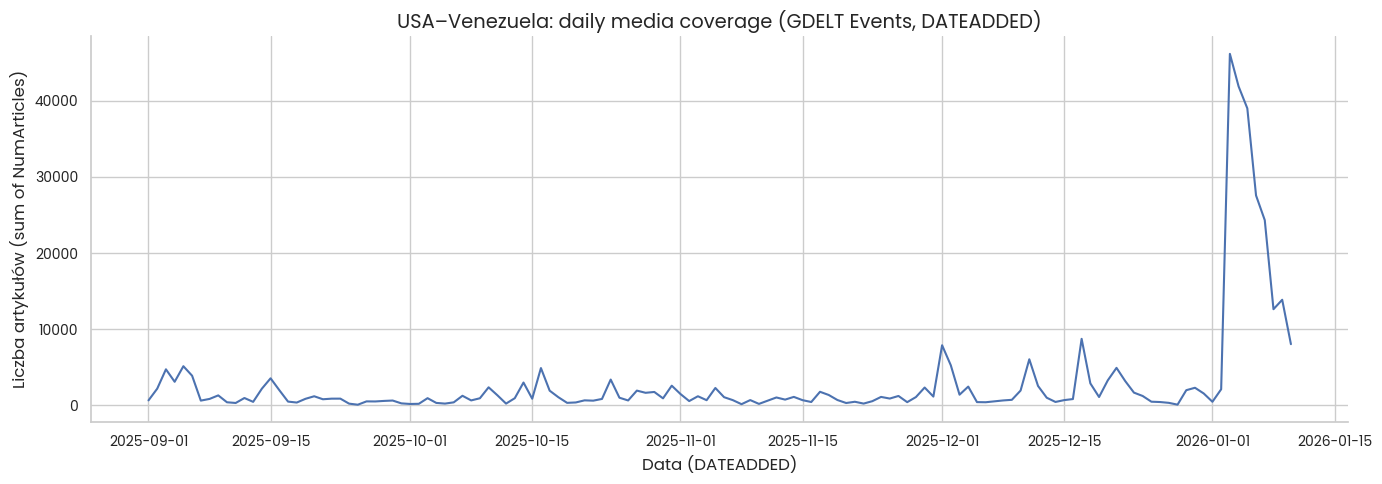

In [16]:
# ===== [15] Wykres dynamiki: liczba artykułów dziennie (num_articles) =====

import pandas as pd
import matplotlib.pyplot as plt

daily_path = "/content/drive/MyDrive/gdelt_trump_venezuela/02_curated/daily_usa_venezuela_dateadded.parquet"

pdf = pd.read_parquet(daily_path)
pdf["date_added"] = pd.to_datetime(pdf["date_added"])
pdf = pdf.sort_values("date_added")

plt.figure(figsize=(14, 5))
plt.plot(pdf["date_added"], pdf["num_articles"])
plt.xlabel("Data (DATEADDED)")
plt.ylabel("Liczba artykułów (sum of NumArticles)")
plt.title("USA–Venezuela: daily media coverage (GDELT Events, DATEADDED)")
plt.tight_layout()
sns.despine()
plt.show()





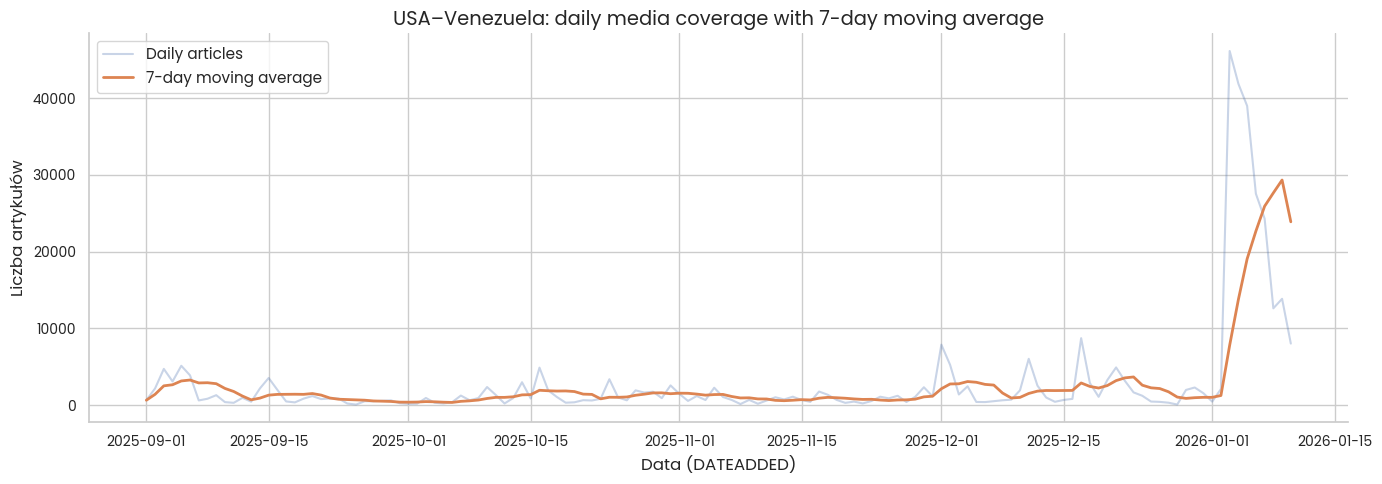

In [17]:
# ===== [16] Wygładzenie szeregu czasowego: 7-dniowa średnia krocząca =====

import pandas as pd
import matplotlib.pyplot as plt

daily_path = "/content/drive/MyDrive/gdelt_trump_venezuela/02_curated/daily_usa_venezuela_dateadded.parquet"

pdf = pd.read_parquet(daily_path)
pdf["date_added"] = pd.to_datetime(pdf["date_added"])
pdf = pdf.sort_values("date_added")

# 7-dniowa średnia krocząca
pdf["num_articles_ma7"] = pdf["num_articles"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(pdf["date_added"], pdf["num_articles"], alpha=0.3, label="Daily articles")
plt.plot(pdf["date_added"], pdf["num_articles_ma7"], linewidth=2, label="7-day moving average")
plt.xlabel("Data (DATEADDED)")
plt.ylabel("Liczba artykułów")
plt.title("USA–Venezuela: daily media coverage with 7-day moving average")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()





In [18]:
import pandas as pd

daily_path = "/content/drive/MyDrive/gdelt_trump_venezuela/02_curated/daily_usa_venezuela_dateadded.parquet"

pdf = pd.read_parquet(daily_path)
pdf["date_added"] = pd.to_datetime(pdf["date_added"])

top_days = (
    pdf.sort_values("num_articles", ascending=False)
       .head(7)
       .sort_values("date_added")
)

print("TOP 7 dni pod względem liczby artykułów (USA–Wenezuela):")
top_days[["date_added", "num_articles", "num_events", "num_sources"]]




TOP 7 dni pod względem liczby artykułów (USA–Wenezuela):


,date_added,num_articles,num_events,num_sources
124,2026-01-03,46153.0,2693,14406.0
125,2026-01-04,41881.0,3575,13974.0
126,2026-01-05,39000.0,3449,11433.0
127,2026-01-06,27562.0,2688,9301.0
128,2026-01-07,24323.0,2066,7111.0
129,2026-01-08,12626.0,1636,4374.0
130,2026-01-09,13867.0,1596,4376.0


## Struktura zdarzeń w piku (CAMEO)
Poniżej badamy strukturę typów zdarzeń w oknie piku (03–09.01).
Łączymy kody CAMEO z opisami, aby wnioski były interpretowalne.


In [19]:
# ===== [18] Struktura zdarzeń w okresie piku + automatyczne opisy CAMEO =====

from pyspark.sql import functions as F
import requests
import pandas as pd
from io import StringIO

# --- 1. Pobranie i sparsowanie CAMEO.eventcodes.txt ---
cameo_url = "https://www.gdeltproject.org/data/lookups/CAMEO.eventcodes.txt"
text = requests.get(cameo_url).text

rows = []
for line in text.splitlines():
    if not line.strip():
        continue
    parts = line.split("\t")
    if len(parts) >= 2:
        rows.append({
            "EventCode": parts[0].strip(),
            "EventDescription": parts[1].strip()
        })

cameo_df = spark.createDataFrame(pd.DataFrame(rows))

print("Liczba kodów CAMEO w lookup:", cameo_df.count())

# --- 2. Przygotowanie zbioru piku ---
peak_dates = [
    "2026-01-03", "2026-01-04", "2026-01-05",
    "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09"
]

df_peak = (
    df_us_ven
    .withColumn("date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd"))
    .filter(F.col("date_added").isin(peak_dates))
)

# --- 3. Agregacja + JOIN z opisami CAMEO ---
df_peak_events = (
    df_peak
    .groupBy("EventCode")
    .agg(
        F.count("*").alias("num_events"),
        F.sum("NumArticles").alias("num_articles"),
        F.sum("NumSources").alias("num_sources")
    )
    .join(cameo_df, on="EventCode", how="left")
    .orderBy(F.desc("num_articles"))
)

df_peak_events.show(20, truncate=False)





Liczba kodów CAMEO w lookup: 311
+---------+----------+------------+-----------+-----------------------------------------------------+
|EventCode|num_events|num_articles|num_sources|EventDescription                                     |
+---------+----------+------------+-----------+-----------------------------------------------------+
|173      |1116      |15855.0     |5754.0     |Arrest, detain, or charge with legal action          |
|010      |1240      |15731.0     |5195.0     |Make statement, not specified below                  |
|042      |1025      |13048.0     |4176.0     |Make a visit                                         |
|043      |878       |12543.0     |3825.0     |Host a visit                                         |
|190      |1081      |12149.0     |3613.0     |Use conventional military force, not specified below |
|051      |1020      |10795.0     |3544.0     |Praise or endorse                                    |
|112      |717       |10505.0     |4079.0     |Ac

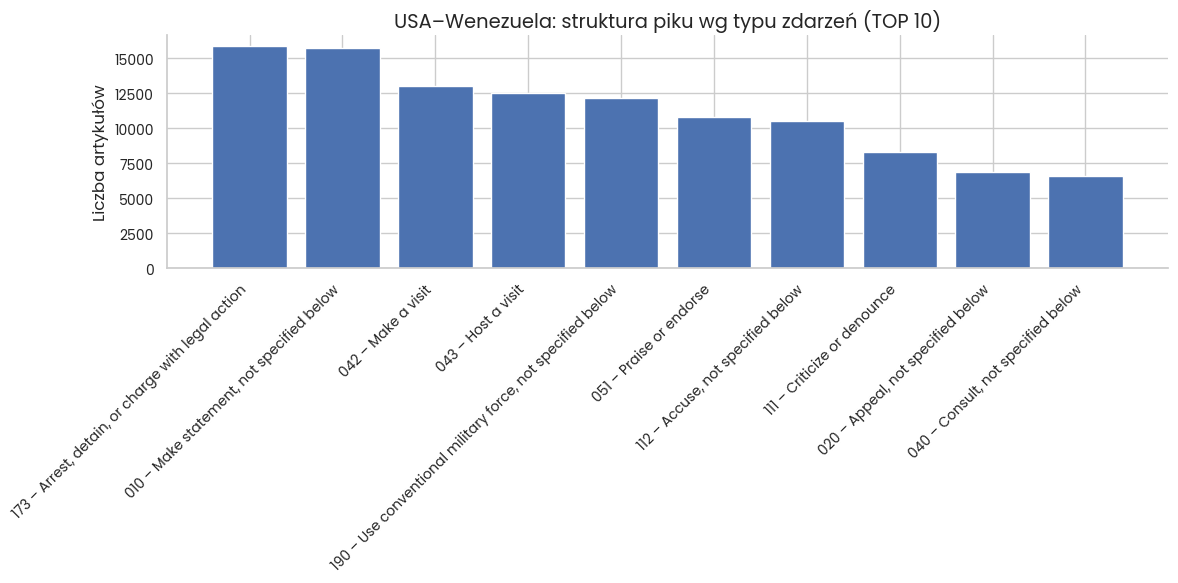

In [20]:
# ===== [19] Wykres kolumnowy: struktura piku wg EventCode (num_articles) =====

import pandas as pd
import matplotlib.pyplot as plt

# zakładamy, że df_peak_events z Komórki 18 już istnieje
pdf_peak = df_peak_events.toPandas()

# bierzemy TOP 10 eventów wg liczby artykułów
pdf_top = pdf_peak.sort_values("num_articles", ascending=False).head(10)

# etykiety: "CODE – Description"
labels = pdf_top["EventCode"] + " – " + pdf_top["EventDescription"]

plt.figure(figsize=(12, 6))
plt.bar(labels, pdf_top["num_articles"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Liczba artykułów")
plt.title("USA–Wenezuela: struktura piku wg typu zdarzeń (TOP 10)")
plt.tight_layout()
sns.despine()
plt.show()





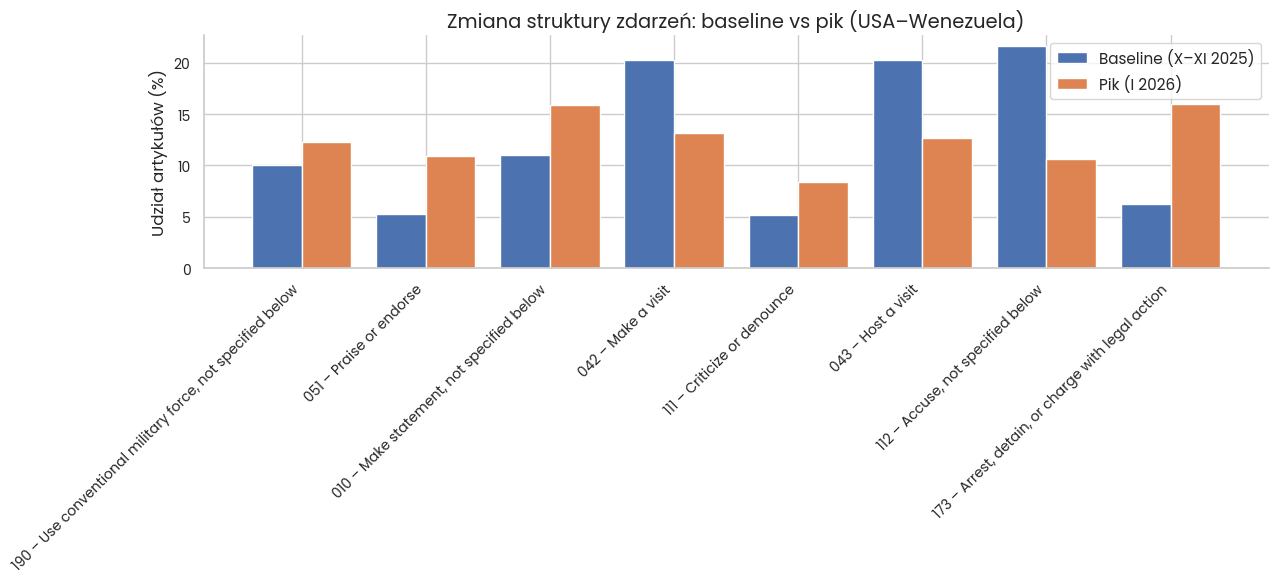

In [21]:
# ===== [20] Porównanie struktury zdarzeń: baseline vs peak (udziały %) =====

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

# --- definicja okresów ---
baseline_start = "2025-10-01"
baseline_end   = "2025-11-30"

peak_dates = [
    "2026-01-03", "2026-01-04", "2026-01-05",
    "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09"
]

df_all = df_us_ven.withColumn(
    "date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd")
)

# --- baseline ---
df_baseline = df_all.filter(
    (F.col("date_added") >= baseline_start) &
    (F.col("date_added") <= baseline_end)
)

baseline_events = (
    df_baseline.groupBy("EventCode")
    .agg(F.sum("NumArticles").alias("articles"))
)

# --- peak ---
peak_events = (
    df_all.filter(F.col("date_added").isin(peak_dates))
    .groupBy("EventCode")
    .agg(F.sum("NumArticles").alias("articles"))
)

# --- join z opisami CAMEO ---
baseline_pd = baseline_events.join(cameo_df, "EventCode", "left").toPandas()
peak_pd     = peak_events.join(cameo_df, "EventCode", "left").toPandas()

# --- TOP 8 eventów wg piku ---
top_codes = (
    peak_pd.sort_values("articles", ascending=False)
    .head(8)["EventCode"]
)

baseline_pd = baseline_pd[baseline_pd["EventCode"].isin(top_codes)]
peak_pd     = peak_pd[peak_pd["EventCode"].isin(top_codes)]

# --- normalizacja do % ---
baseline_pd["share"] = baseline_pd["articles"] / baseline_pd["articles"].sum() * 100
peak_pd["share"]     = peak_pd["articles"] / peak_pd["articles"].sum() * 100

# --- merge ---
cmp = baseline_pd.merge(
    peak_pd,
    on=["EventCode", "EventDescription"],
    suffixes=("_baseline", "_peak")
)

# --- wykres ---
labels = cmp["EventCode"] + " – " + cmp["EventDescription"]

x = range(len(labels))
plt.figure(figsize=(13,6))
plt.bar(x, cmp["share_baseline"], width=0.4, label="Baseline (X–XI 2025)")
plt.bar([i+0.4 for i in x], cmp["share_peak"], width=0.4, label="Pik (I 2026)")

plt.xticks([i+0.2 for i in x], labels, rotation=45, ha="right")
plt.ylabel("Udział artykułów (%)")
plt.title("Zmiana struktury zdarzeń: baseline vs pik (USA–Wenezuela)")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()





## Case study: EventCode 173 (areszt) w oknie piku
Przeglądamy top artykuły i źródła dla zdarzeń typu **173 (areszt)** w okresie piku,
aby zobaczyć, jakie źródła i narracje dominują w kluczowym zdarzeniu.


In [22]:
# ===== [21] TOP artykuły w piku dla EventCode 173 =====

from pyspark.sql import functions as F

df_173_peak = (
    df_all
    .filter(F.col("EventCode") == "173")
    .filter(F.col("date_added").isin(peak_dates))
    .select(
        "date_added",
        "Actor1Name", "Actor2Name",
        "NumArticles", "NumSources",
        "SOURCEURL"
    )
    .orderBy(F.desc("NumArticles"))
)

df_173_peak.show(15, truncate=140)





+----------+--------------+----------------+-----------+----------+--------------------------------------------------------------------------------------------------------------------------------------------+
|date_added|    Actor1Name|      Actor2Name|NumArticles|NumSources|                                                                                                                                   SOURCEURL|
+----------+--------------+----------------+-----------+----------+--------------------------------------------------------------------------------------------------------------------------------------------+
|2026-01-05| UNITED STATES|       VENEZUELA|         99|        43|                                                     https://www.oann.com/newsroom/maduro-set-to-appear-in-new-york-federal-court-on-monday/|
|2026-01-04|      NEW YORK|       VENEZUELA|        985|        73|                                                     https://www.theadvocate.com.au/story/9144824

## Dynamika konfliktu i współpracy (QuadClass)
Wykresy QuadClass pokazują, czy dominują narracje konfliktowe czy kooperacyjne oraz
czy konflikt ma charakter werbalny czy materialny.


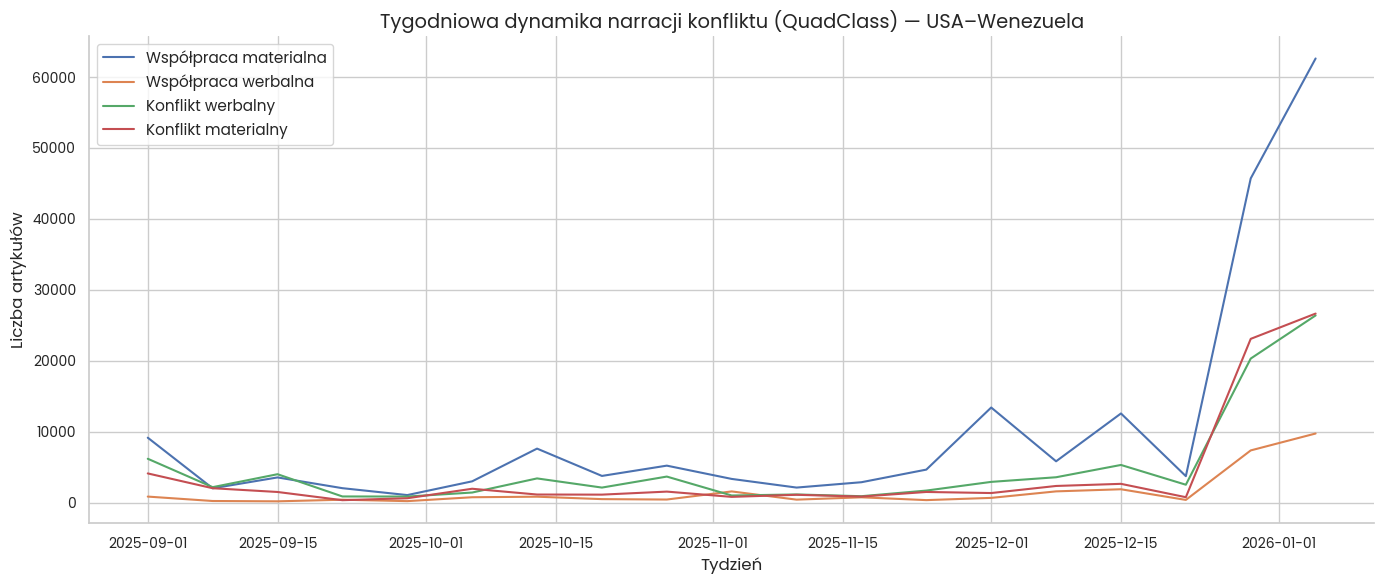

In [23]:
# ===== Wykres liniowy QuadClass (tygodniowo) =====

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

quad_labels = {
    "1": "Współpraca materialna",
    "2": "Współpraca werbalna",
    "3": "Konflikt werbalny",
    "4": "Konflikt materialny"
}

# 1) Spark: przygotowanie i agregacja tygodniowa
df_q = (
    df_us_ven
    .withColumn("date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd"))
    .withColumn("week", F.date_trunc("week", F.col("date_added")))
)

weekly_quad = (
    df_q
    .groupBy("week", "QuadClass")
    .agg(F.sum("NumArticles").alias("num_articles"))
)

# 2) Pandas: pivot
pdf = weekly_quad.toPandas()
pdf["week"] = pd.to_datetime(pdf["week"])
pdf = pdf.sort_values("week")

pivot = pdf.pivot_table(
    index="week",
    columns="QuadClass",
    values="num_articles",
    fill_value=0
)

# 3) Wykres
plt.figure(figsize=(14, 6))

for qc, label in quad_labels.items():
    if qc in pivot.columns:
        plt.plot(pivot.index, pivot[qc], label=label)

plt.xlabel("Tydzień")
plt.ylabel("Liczba artykułów")
plt.title("Tygodniowa dynamika narracji konfliktu (QuadClass) — USA–Wenezuela")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()





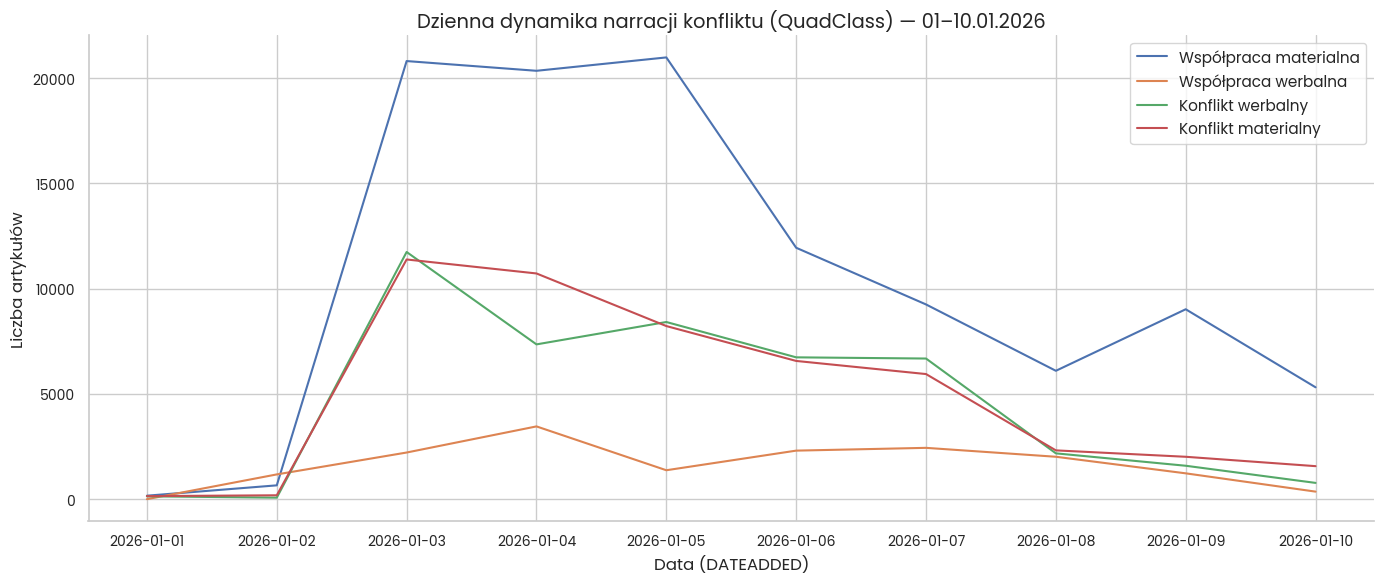

In [24]:
# ===== Wykres liniowy QuadClass (dziennie, 01–10.01.2026) =====

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

quad_labels = {
    "1": "Współpraca materialna",
    "2": "Współpraca werbalna",
    "3": "Konflikt werbalny",
    "4": "Konflikt materialny"
}

start_date = "2026-01-01"
end_date   = "2026-01-10"

# 1) Spark: filtr + agregacja dzienna
df_d = (
    df_us_ven
    .withColumn("date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd"))
    .filter((F.col("date_added") >= start_date) & (F.col("date_added") <= end_date))
)

daily_quad = (
    df_d
    .groupBy("date_added", "QuadClass")
    .agg(F.sum("NumArticles").alias("num_articles"))
)

# 2) Pandas: pivot
pdf = daily_quad.toPandas()
pdf["date_added"] = pd.to_datetime(pdf["date_added"])
pdf = pdf.sort_values("date_added")

pivot = pdf.pivot_table(
    index="date_added",
    columns="QuadClass",
    values="num_articles",
    fill_value=0
)

# 3) Wykres
plt.figure(figsize=(14, 6))

for qc, label in quad_labels.items():
    if qc in pivot.columns:
        plt.plot(pivot.index, pivot[qc], label=label)

plt.xlabel("Data (DATEADDED)")
plt.ylabel("Liczba artykułów")
plt.title("Dzienna dynamika narracji konfliktu (QuadClass) — 01–10.01.2026")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()





## Analiza statystyczna i rozkłady (Pandas)
W tej części wykonujemy podstawowe statystyki opisowe, analizę rozkładów oraz testy statystyczne
na agregatach dziennych. To spełnia wymagania dotyczące analizy statystycznej.


,date_added,num_events,num_articles,num_sources
count,132,132.000000,132.000000,132.000000
mean,2025-11-05 12:00:00,292.128788,2955.431818,938.310606
min,2025-09-01 00:00:00,26.000000,87.000000,26.000000
25%,2025-10-03 18:00:00,85.750000,525.250000,168.500000
50%,2025-11-05 12:00:00,142.000000,943.000000,313.500000
75%,2025-12-08 06:00:00,230.000000,2133.250000,704.250000
max,2026-01-10 00:00:00,3575.000000,46153.000000,14406.000000
std,NaN,572.147560,7070.170017,2239.694939


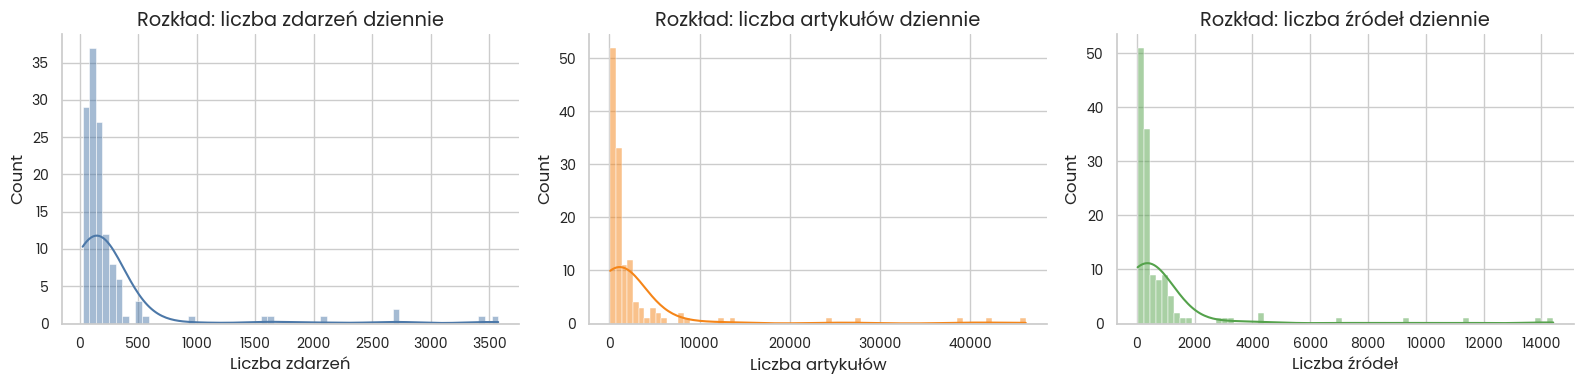

In [27]:
# ===== Analiza statystyczna: statystyki opisowe i rozkłady =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# baza: dzienna agregacja (df_daily) -> Pandas
daily_pd = df_daily.toPandas()
daily_pd['date_added'] = pd.to_datetime(daily_pd['date_added'])

display(daily_pd.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(daily_pd['num_events'], kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Rozkład: liczba zdarzeń dziennie')
axes[0].set_xlabel('Liczba zdarzeń')

sns.histplot(daily_pd['num_articles'], kde=True, ax=axes[1], color='#F58518')
axes[1].set_title('Rozkład: liczba artykułów dziennie')
axes[1].set_xlabel('Liczba artykułów')

sns.histplot(daily_pd['num_sources'], kde=True, ax=axes[2], color='#54A24B')
axes[2].set_title('Rozkład: liczba źródeł dziennie')
axes[2].set_xlabel('Liczba źródeł')

plt.tight_layout()
sns.despine()
plt.show()


## Zaawansowana analiza szeregów czasowych (Pandas)
Wyznaczamy trend kroczący i prostą predykcję (rolling/średnia) jako element analizy zaawansowanej.


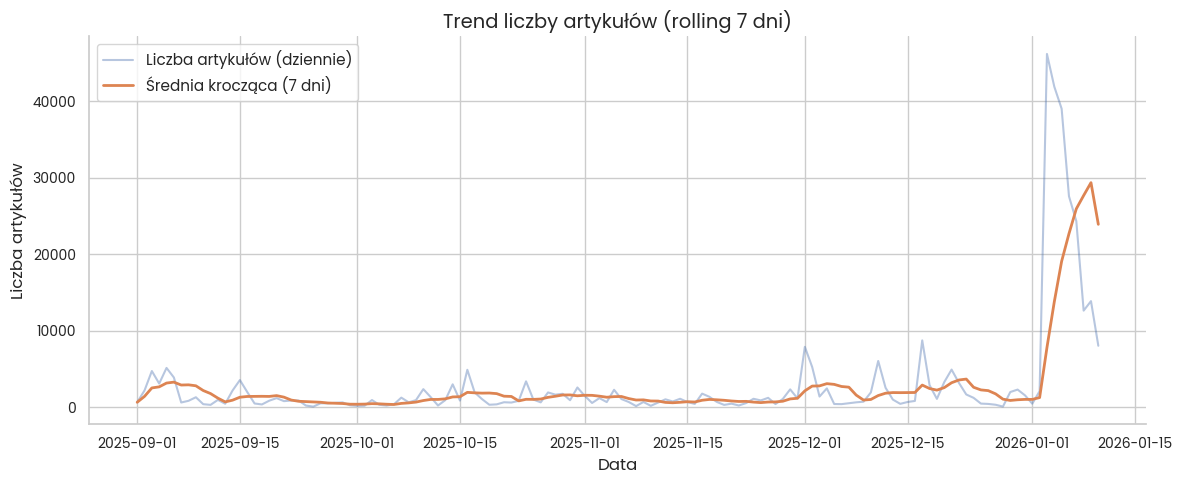

Prosta prognoza na kolejne 7 dni (średnia krocząca): 23899.29


In [30]:
import pandas as pd
# ===== Szeregi czasowe: trend kroczący i prosta predykcja =====
daily_pd = daily_pd.sort_values('date_added')
daily_pd['rolling_7'] = daily_pd['num_articles'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_pd['date_added'], daily_pd['num_articles'], label='Liczba artykułów (dziennie)', alpha=0.4)
plt.plot(daily_pd['date_added'], daily_pd['rolling_7'], label='Średnia krocząca (7 dni)', linewidth=2)
plt.title('Trend liczby artykułów (rolling 7 dni)')
plt.xlabel('Data')
plt.ylabel('Liczba artykułów')
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

# Prosta predykcja: prognoza na 7 dni jako ostatnia średnia krocząca
last_value = daily_pd['rolling_7'].iloc[-1]
print(f'Prosta prognoza na kolejne 7 dni (średnia krocząca): {last_value:.2f}')



### Testy statystyczne (przykład)
Testujemy różnicę między okresem bazowym (X–XI 2025) a oknem piku (03–09.01.2026)
dla dziennej liczby artykułów.


In [29]:
# ===== Test statystyczny: baseline vs peak (num_articles) =====
import pandas as pd
from scipy import stats

baseline_mask = (daily_pd['date_added'] >= '2025-10-01') & (daily_pd['date_added'] <= '2025-11-30')
peak_mask = (daily_pd['date_added'] >= '2026-01-03') & (daily_pd['date_added'] <= '2026-01-09')

baseline_series = daily_pd.loc[baseline_mask, 'num_articles']
peak_series = daily_pd.loc[peak_mask, 'num_articles']

t_stat, p_val = stats.ttest_ind(peak_series, baseline_series, equal_var=False)
print('Test t-Studenta (Welcha) dla num_articles:')
print(f't = {t_stat:.3f}, p = {p_val:.4f}')



Test t-Studenta (Welcha) dla num_articles:
t = 5.572, p = 0.0014


## Ton narracji i siła zdarzeń
AvgTone opisuje ogólny wydźwięk materiałów, a GoldsteinScale przybliża natężenie
konfliktu/współpracy. Oba wskaźniki są ważone liczbą artykułów.


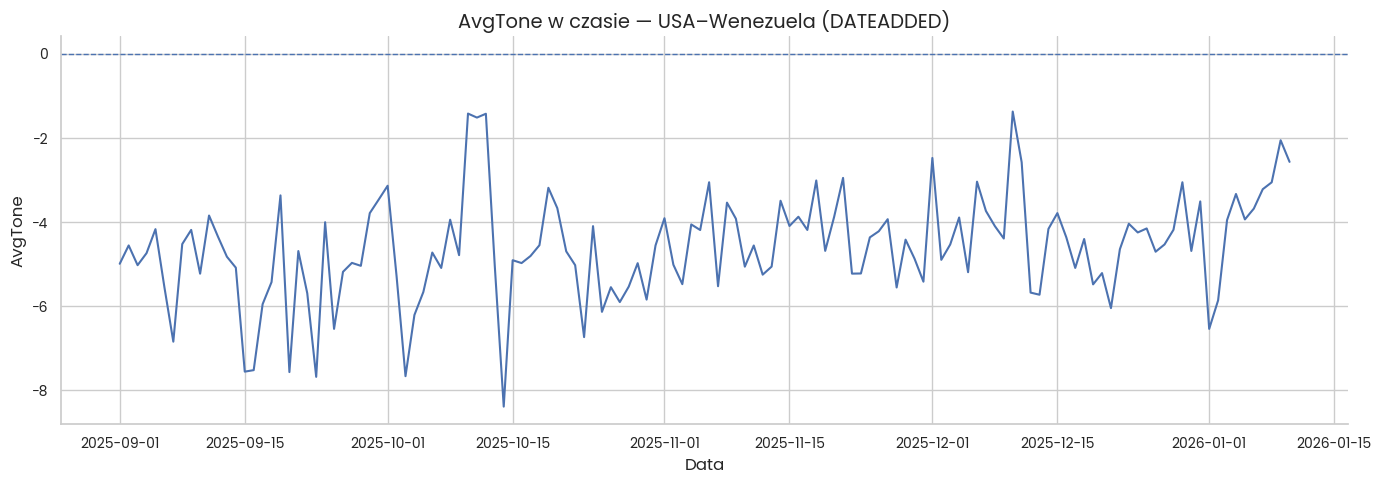

In [28]:
# ===== AvgTone w czasie (2025-09-01 do 2026-01-10) =====

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2025-09-01"
end_date   = "2026-01-10"

# 1) Przygotowanie danych
df_tone = (
    df_us_ven
    .withColumn("date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd"))
    .filter((F.col("date_added") >= start_date) & (F.col("date_added") <= end_date))
)

# 2) Agregacja dzienna AvgTone (ważona liczbą artykułów)
daily_tone = (
    df_tone
    .groupBy("date_added")
    .agg(
        (F.sum(F.col("AvgTone") * F.col("NumArticles")) /
         F.sum("NumArticles")).alias("avg_tone")
    )
    .orderBy("date_added")
)

# 3) Spark → pandas
pdf = daily_tone.toPandas()
pdf["date_added"] = pd.to_datetime(pdf["date_added"])

# 4) Wykres
plt.figure(figsize=(14, 5))
plt.plot(pdf["date_added"], pdf["avg_tone"])
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Data")
plt.ylabel("AvgTone")
plt.title("AvgTone w czasie — USA–Wenezuela (DATEADDED)")
plt.tight_layout()
sns.despine()
plt.show()





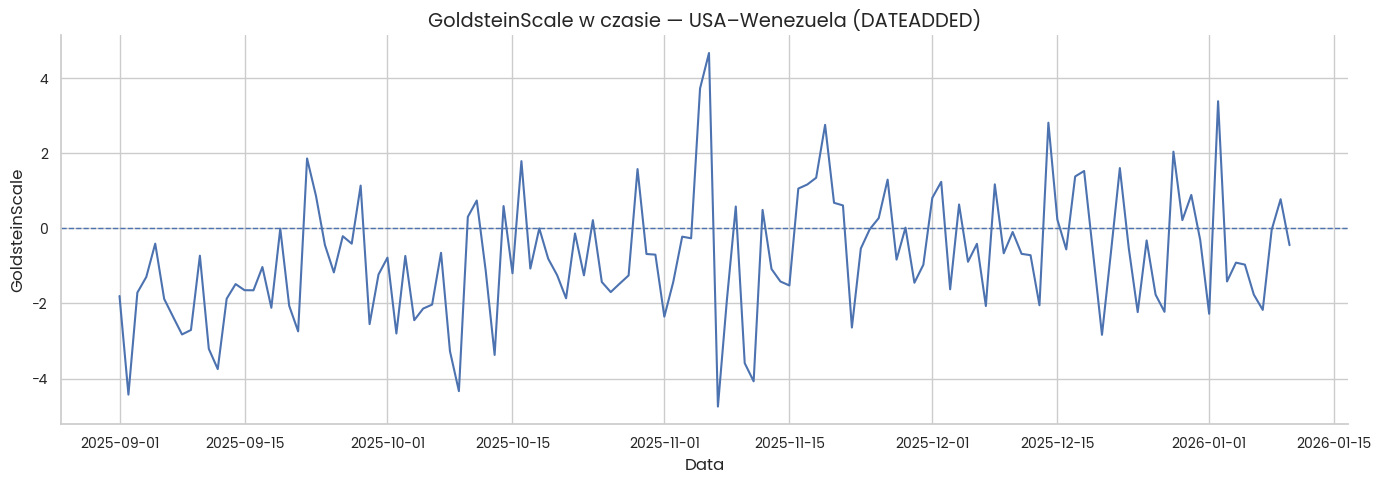

In [31]:
# ===== GoldsteinScale w czasie (2025-09-01 do 2026-01-10) =====

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2025-09-01"
end_date   = "2026-01-10"

# 1) Przygotowanie danych
df_gold = (
    df_us_ven
    .withColumn("date_added", F.to_date(F.col("DATEADDED").cast("string"), "yyyyMMdd"))
    .filter((F.col("date_added") >= start_date) & (F.col("date_added") <= end_date))
)

# 2) Agregacja dzienna GoldsteinScale (ważona NumArticles)
daily_gold = (
    df_gold
    .groupBy("date_added")
    .agg(
        (F.sum(F.col("GoldsteinScale") * F.col("NumArticles")) /
         F.sum("NumArticles")).alias("goldstein_scale")
    )
    .orderBy("date_added")
)

# 3) Spark → pandas
pdf = daily_gold.toPandas()
pdf["date_added"] = pd.to_datetime(pdf["date_added"])

# 4) Wykres
plt.figure(figsize=(14, 5))
plt.plot(pdf["date_added"], pdf["goldstein_scale"])
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Data")
plt.ylabel("GoldsteinScale")
plt.title("GoldsteinScale w czasie — USA–Wenezuela (DATEADDED)")
plt.tight_layout()
sns.despine()
plt.show()





## Dashboard (zbiorcza wizualizacja)
Tworzymy zestaw najważniejszych wykresów w jednym układzie, aby ułatwić prezentację wyników.


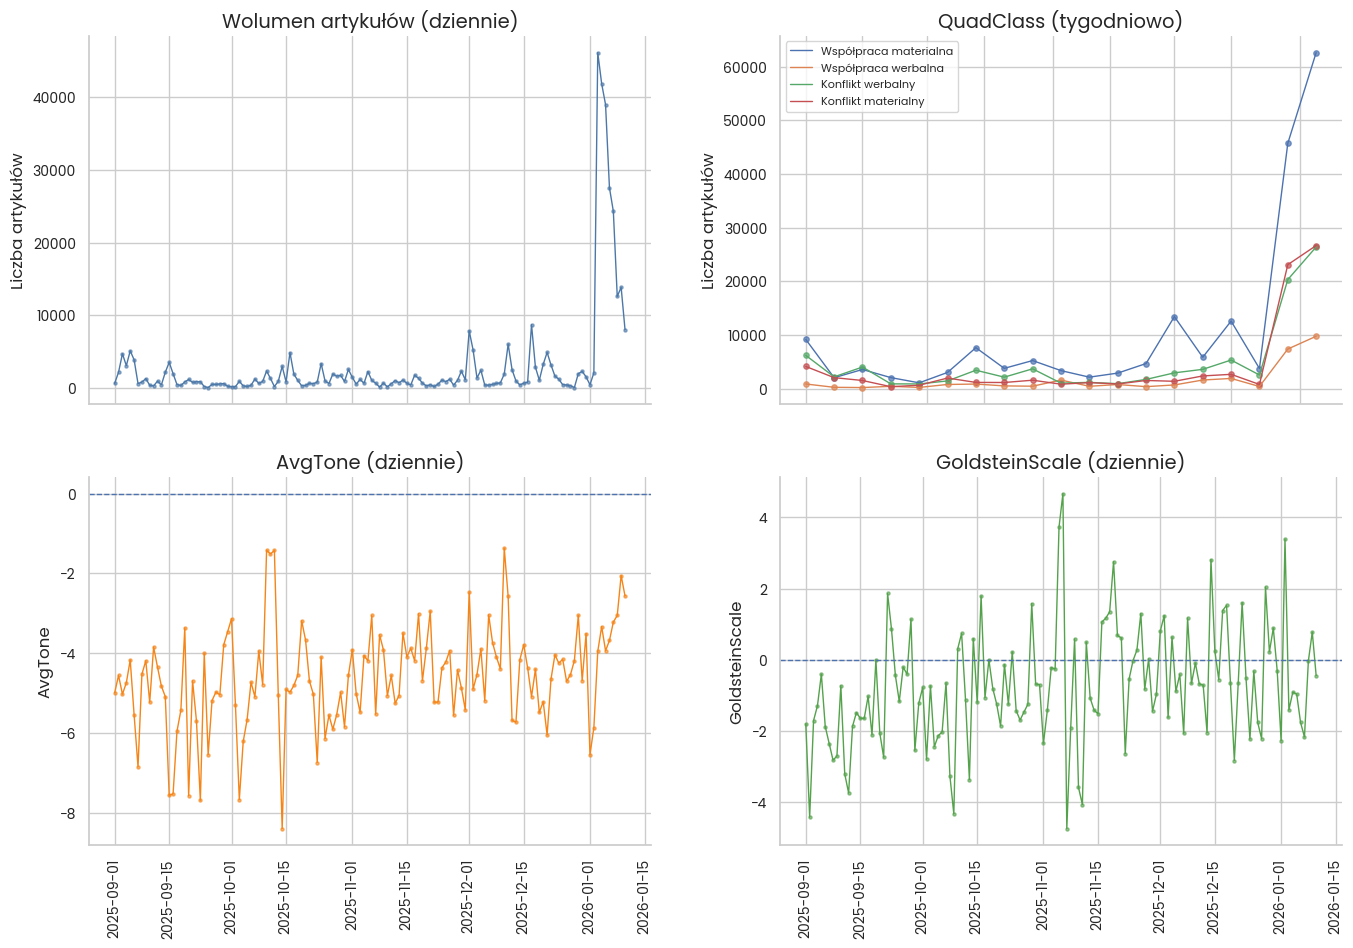

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Przygotowanie danych
# =========================

daily_pd = df_daily.toPandas()
daily_pd['date_added'] = pd.to_datetime(daily_pd['date_added'])

avg_pd = daily_tone.toPandas()
avg_pd['date_added'] = pd.to_datetime(avg_pd['date_added'])

gold_pd = daily_gold.toPandas()
gold_pd['date_added'] = pd.to_datetime(gold_pd['date_added'])

pivot = weekly_quad.toPandas()
pivot['week'] = pd.to_datetime(pivot['week'])
pivot = pivot.pivot_table(
    index='week',
    columns='QuadClass',
    values='num_articles',
    fill_value=0
)

# =========================
# Dashboard
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ---- (1) Wolumen artykułów (dziennie)
axes[0, 0].plot(
    daily_pd['date_added'],
    daily_pd['num_articles'],
    color='#4C78A8',
    linewidth=1
)
axes[0, 0].scatter(
    daily_pd['date_added'],
    daily_pd['num_articles'],
    color='#4C78A8',
    s=5,
    alpha=0.6
)
axes[0, 0].set_title('Wolumen artykułów (dziennie)')
axes[0, 0].set_ylabel('Liczba artykułów')

# ---- (2) QuadClass (tygodniowo)
for qc, label in quad_labels.items():
    if qc in pivot.columns:
        axes[0, 1].plot(
            pivot.index,
            pivot[qc],
            label=label,
            linewidth=1
        )
        axes[0, 1].scatter(
            pivot.index,
            pivot[qc],
            s=15,
            alpha=0.7
        )

axes[0, 1].set_title('QuadClass (tygodniowo)')
axes[0, 1].set_ylabel('Liczba artykułów')
axes[0, 1].legend(fontsize=8)

# ---- (3) AvgTone (dziennie)
axes[1, 0].plot(
    avg_pd['date_added'],
    avg_pd['avg_tone'],
    color='#F58518',
    linewidth=1
)
axes[1, 0].scatter(
    avg_pd['date_added'],
    avg_pd['avg_tone'],
    color='#F58518',
    s=5,
    alpha=0.6
)
axes[1, 0].axhline(0, linestyle='--', linewidth=1)
axes[1, 0].set_title('AvgTone (dziennie)')
axes[1, 0].set_ylabel('AvgTone')

# ---- (4) GoldsteinScale (dziennie)
axes[1, 1].plot(
    gold_pd['date_added'],
    gold_pd['goldstein_scale'],
    color='#54A24B',
    linewidth=1
)
axes[1, 1].scatter(
    gold_pd['date_added'],
    gold_pd['goldstein_scale'],
    color='#54A24B',
    s=5,
    alpha=0.6
)
axes[1, 1].axhline(0, linestyle='--', linewidth=1)
axes[1, 1].set_title('GoldsteinScale (dziennie)')
axes[1, 1].set_ylabel('GoldsteinScale')

# =========================
# Layout i osie
# =========================

plt.tight_layout()

# Ukrycie etykiet X w górnym rzędzie
for ax in axes[0, :]:
    ax.tick_params(axis='x', labelbottom=False)

# Obrót etykiet X w dolnym rzędzie
for ax in axes[1, :]:
    ax.tick_params(axis='x', rotation=90)

sns.despine()
plt.show()


## Dokumentacja projektu (raport i prezentacja)
Na potrzeby zaliczenia przygotowujemy dodatkowo:
- **Raport w Word**: streszczenie danych, metodologia, wyniki i wnioski z wykresami.
- **Prezentacja PowerPoint**: slajdy z kluczowymi wykresami (dashboard, CAMEO, QuadClass, AvgTone, Goldstein).


## Wnioski (podsumowanie)
W ostatniej części raportu syntetyzujemy wyniki: dynamikę wolumenu, zmianę struktury CAMEO, przesunięcie QuadClass oraz trend tonu/GoldsteinScale.
Wnioski formułujemy w odniesieniu do hipotez H1–H5, z naciskiem na interpretację zmian w oknie 03–09.01.2026.
